<a href="https://colab.research.google.com/github/tixomirof/mo2_team_colabs/blob/main/%D0%9C%D0%9E2_%D0%9A%D0%BE%D0%BC%D0%B0%D0%BD%D0%B4%D0%B02_%D0%9B%D0%B0%D0%B105_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Шапка

Проектная работа. Группа №2. Обучение с учителем: SVM.

Участники команды:
* Ибраева Асем
* Киреева Анастасия
* Рудин Валентин
* Тихомиров Алексей

# Метод SVM

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay,
                             precision_recall_curve,
                             PrecisionRecallDisplay,
                             RocCurveDisplay)

Загрузим датасет, полученный в первой лабораторной работе

In [ ]:
df = pd.read_csv('Engineered_Data.csv')
df.head()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev
0,1,7.0,4,51552.0,4,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,12.0,5,46482.0,12,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
2,1,15.0,6,77290.0,7,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,9.0,6,46135.0,13,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
4,0,40.0,30,160932.0,2,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
df['Employed'].unique()

array([0, 1])

In [ ]:
df[df.isna().any(axis=1)]




,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev


Проверим, что в датасете нет пропусков

In [ ]:
df.isnull().sum()

,0
Employment,0
YearsCode,0
YearsCodePro,0
PreviousSalary,0
ComputerSkills,0
...,...
EdLevel_Undergraduate,0
Gender_NonBinary,0
Gender_Woman,0
MentalHealth_Yes,0


In [ ]:
# Только столбцы, содержащие null значения
df.isnull().sum()[df.isnull().sum() > 0]

,0


Выведем статистический отчёт о числовых колонках

In [ ]:
df.describe()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm,gdp
count,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,...,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.00000,69686.000000,69686.000000,6.968600e+04
mean,0.883119,14.250753,9.059725,68058.053124,13.414416,0.535273,0.002856,0.137976,0.171742,0.429943,...,0.057917,0.019545,0.045475,0.024122,0.159917,0.020391,0.20789,0.255589,0.231496,7.039715e+12
std,0.321281,9.383279,7.932900,49362.776837,7.036527,0.498758,0.053362,0.344877,0.377159,0.495071,...,0.233588,0.138431,0.208346,0.153431,0.366532,0.141336,0.40580,0.436195,0.421791,1.034076e+13
min,0.000000,0.000000,0.000000,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,6.540000e+08
25%,1.000000,7.000000,3.000000,29436.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.456290e+11
50%,1.000000,12.000000,7.000000,58034.500000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.173666e+12
75%,1.000000,20.000000,12.000000,95979.000000,17.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,4.456081e+12
max,1.000000,50.000000,50.000000,224000.000000,107.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,2.736094e+13


Выведем количество точек для каждого значения Employed

In [ ]:
df['Employed'].value_counts()

,count
Employed,
1,37301
0,32385


<Axes: xlabel='Employed', ylabel='count'>

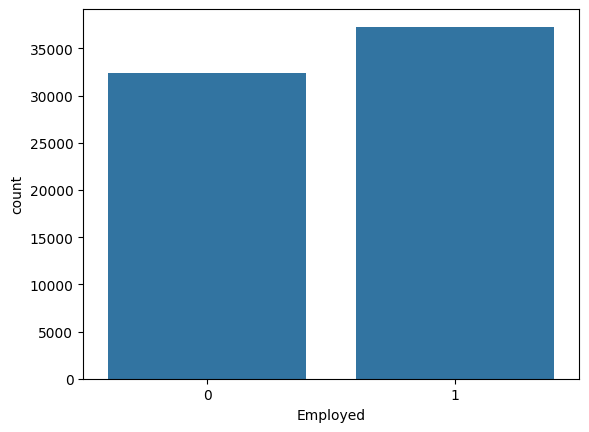

In [ ]:
sns.countplot(data=df, x='Employed')

Можно заметить, что классы сбалансированы

##Разбиение на обучающий и тестовый наборы данных

Разделим все признаки на 2 объекта, X и y

In [ ]:
X = df.drop('Employed',axis=1)
y = df['Employed']

Разделим данные на обучающий и тестовый наборы данных. Для тестовых данных используем размер 10%

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

Промасштабируем данные

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

##Модель логистической регрессии

In [ ]:
from sklearn.svm import SVC

In [ ]:
base_model = SVC()

In [ ]:
dd = pd.DataFrame(scaled_X_train)
dd = dd

In [ ]:
base_model.fit(scaled_X_train,y_train)

SVC()

In [ ]:
base_preds = base_model.predict(scaled_X_test)

Произведем оценку модели

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [ ]:
np.sqrt(mean_squared_error(y_test,base_preds))

np.float64(0.07763175655287137)

In [ ]:
y_test.mean()

np.float64(0.5418280958530636)

Выполняем поиск по сетке

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.svm import SVC


In [ ]:
svm = SVC()
param_grid = {'C':[0.005,0.01,0.05,0.1,1,10],'kernel':['linear','rbf', 'poly']}
grid = GridSearchCV(svm,param_grid)

In [ ]:
grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.005, 0.01, 0.05, 0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
grid.best_params_

{'C': 0.005, 'kernel': 'linear'}

In [ ]:
grid.best_score_

np.float64(1.0)

In [ ]:
grid_preds = grid.predict(scaled_X_test)

In [ ]:
np.sqrt(mean_squared_error(y_test,grid_preds))

np.float64(0.0)

In [ ]:
accuracy_score(y_test, grid_preds)

1.0

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


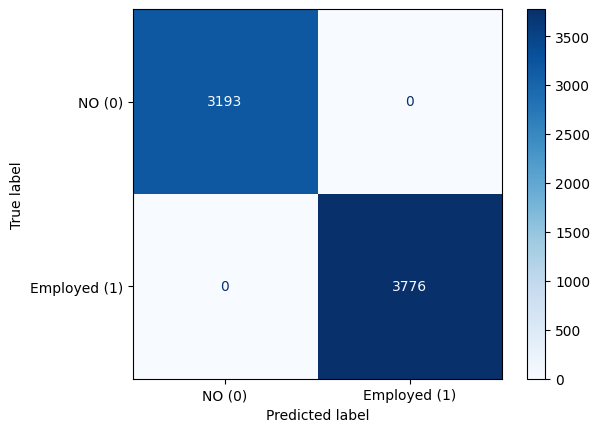

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, grid_preds,
                                        display_labels=['NO (0)', 'Employed (1)'],
                                        cmap='Blues')

In [ ]:
print(classification_report(y_test, grid_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3193
           1       1.00      1.00      1.00      3776

    accuracy                           1.00      6969
   macro avg       1.00      1.00      1.00      6969
weighted avg       1.00      1.00      1.00      6969



Точность стала 100% после подбора параметров, как и в случае модели логистической регрессии.